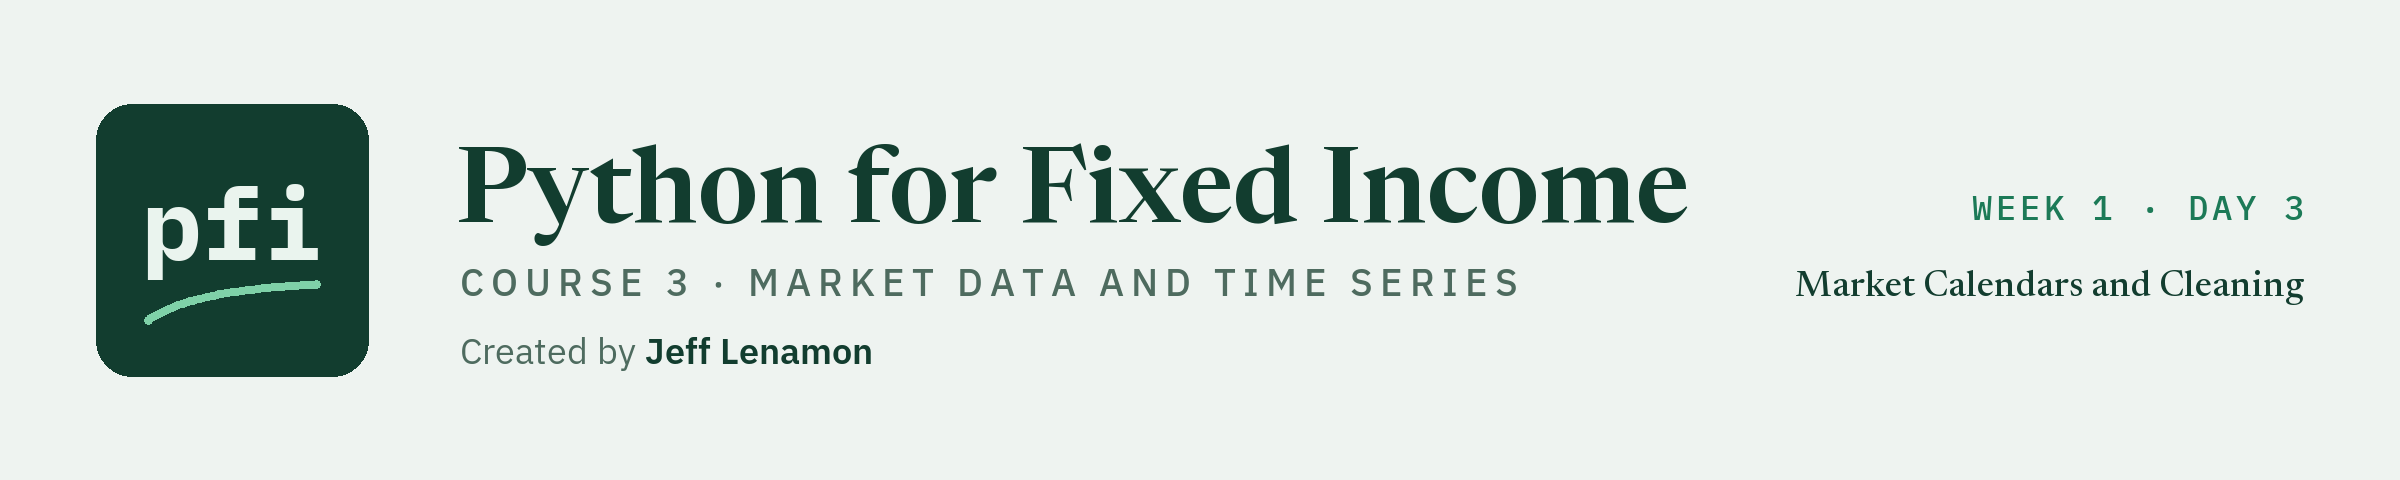

# Market Calendars and Cleaning

Week 1, Day 3. A market series has gaps: weekends, holidays, and a few other weekdays with no row. Today: the market's own calendar, why a holiday calendar is not it, joining two series without inventing days, why forward fill is for display only, and how to find values that stopped updating.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course3_market_data/week1/day3/03_market_calendars_and_cleaning.ipynb)

Yesterday you turned a FRED answer into a dated series. Before you compute anything from it, a change, a window, a join, you need to know **which days the market had**. A daily series does not have a row for every day. It skips weekends, it skips holidays, and it skips a few other weekdays too.

This course's rule is short: **the market's days are the dates the data has.** No holiday list decides them. The Treasury file is the record of which days had a curve, and every calculation in this course runs on those rows and only those.

Today you will:

1. Count calendar days, weekdays, and market days in the Treasury file.
2. Write `missing_weekdays`, and find the weekdays the file has no row for.
3. Compare the file with pandas' federal holiday calendar, and see that they disagree in both directions.
4. Check that FRED's `.` rows and Treasury's absent rows are the same days.
5. Write `align`, which puts series side by side, and see what an outer join puts in the gaps.
6. See what forward fill does to a daily change, and keep it for display only.
7. Write `stale_runs`, which finds a value repeated day after day.

The running data: the Treasury par yield file (the 10 Yr above all) and the course's **synthetic** credit spreads, `course3_synthetic_spreads.csv`. The spreads are invented for this course. They are not ICE, Moody's, or any index.

Q. Set up today's work folder, copy today's three data files into it, and write the start-of-day files.

In [1]:
# today's setup: modules, the course data, a fresh work folder, and the constants the live cells use
import importlib
import os
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

import pandas as pd

# three packages a Colab runtime or a new environment may lack: stop with the line that installs the missing one
for module_name, install_name in [("pytest", "pytest"), ("requests", "requests"), ("dotenv", "python-dotenv")]:
    try:
        importlib.import_module(module_name)
    except ImportError:
        raise RuntimeError(f"{install_name} is not installed. Run  !pip install {install_name}  in a new cell, "
                           "then run this cell again.") from None
import pytest
import requests

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "treasury_par_yields.csv").exists()
data_folder = RAW_DATA if on_github else str(local_data) + os.sep

# 2. your own key file: in your my_bondmath folder, outside every repository. Its path is never printed.
ENV_FILE = Path.home() / "projects" / "my_bondmath" / ".env"

# 3. the two constants of the live cells
NO_KEY_MESSAGE = "Live cell skipped: no FRED key was found. Every other cell runs without one."
# ICE BofA and Moody's values stay off the screen unless you set this to True, on your own machine only
SHOW_LICENSED_VALUES = False

# 4. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course3_03_"))
os.chdir(work)

# 5. copy today's data files into the work folder
DATA_FILES = ["treasury_par_yields.csv", "course3_synthetic_spreads.csv", "course3_fred_format_dgs10.json"]
for name in DATA_FILES:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Data files from {'GitHub' if on_github else 'the data folder of the course repo'}: {', '.join(DATA_FILES) or 'none'}")
print(f"pytest {pytest.__version__}, requests {requests.__version__}")

Work folder: pfi_course3_03_aqi9om27, in your temp folder
Data files from the data folder of the course repo: treasury_par_yields.csv, course3_synthetic_spreads.csv, course3_fred_format_dgs10.json
pytest 9.1.1, requests 2.34.2


Q. Write `bondmath.py`, the reference copy of the module you finished in Course 2.

It is written into the work folder so that every notebook runs, in Colab too, whether or not you took Course 2. To use your own copy instead, run this line in a new cell after the next one:

```python
shutil.copy(Path.home() / "projects" / "my_bondmath" / "bondmath.py", work)
```

The saved outputs of this notebook always come from the reference copy.

In [2]:
%%writefile bondmath.py
"""bondmath: bond math for fixed-rate bullet bonds, checked against Excel.

Written day by day in Python for Fixed Income, Course 2: Bond Math.

Units, the same in every function:
- coupon_pct and yield_pct are annual rates in percent: 7.0 means 7 percent. Excel takes decimals (0.07).
- Prices and accrued interest are per 100 of face.
- Durations are in years, convexity in years squared, spreads in basis points.
- frequency is the number of coupons (or compounding periods) a year: 1, 2, or 4.
- basis is the day count: "30/360" (Excel basis 0) or "ACT/ACT" (Excel basis 1).
- Dates are datetime.date values.
"""
import calendar  # month lengths, used from week 2
from datetime import date  # calendar dates, used from week 2


def future_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Grow an amount at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount x (1 + rate / frequency) ** (frequency x years).
    Excel: =FV(rate_pct/100/frequency, frequency*years, 0, -amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # grow the amount over every period
    return amount * (1 + period_rate) ** periods


def present_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Discount an amount due in `years` at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount / (1 + rate / frequency) ** (frequency x years).
    Returns a positive number for a positive amount. Excel's PV returns the same number with a
    minus sign: =-PV(rate_pct/100/frequency, frequency*years, 0, amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # discount the amount over every period
    return amount / (1 + period_rate) ** periods


def cash_flows(coupon_pct: float, years: float, frequency: int = 2) -> list[tuple[float, float]]:
    """The cash flows of a bullet bond bought on a coupon date.

    Units: coupon_pct in percent of face a year, years in years. Each cash flow is per 100 of face.
    Convention: one coupon of coupon_pct / frequency every 1 / frequency years, and 100 back with
    the last coupon. Returns a list of (time in years, cash flow) pairs, earliest first.
    Raises ValueError unless years x frequency is a whole number of periods.
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # count the coupon periods and check they are whole
    periods = years * frequency
    if periods <= 0 or abs(periods - round(periods)) > 1e-9:
        raise ValueError(f"{years} years is not a whole number of periods at frequency {frequency}")
    periods = round(periods)
    # each coupon is the annual coupon split into equal parts
    coupon = coupon_pct / frequency
    flows = []
    for k in range(1, periods + 1):
        # the time of payment k, in years
        time_years = k / frequency
        # the last payment also returns the face of 100
        amount = coupon + 100 if k == periods else coupon
        flows.append((time_years, amount))
    return flows


def price_from_yield(coupon_pct: float, yield_pct: float, years: float, frequency: int = 2) -> float:
    """Price of a bullet bond on a coupon date, from its yield.

    Units: coupon_pct and yield_pct in percent a year, years in years, price per 100 of face.
    Convention: each cash flow is discounted at yield_pct compounded `frequency` times a year.
    On a coupon date there is no accrued interest, so this is both the clean and the dirty price.
    Excel: =-PV(yield_pct/100/frequency, frequency*years, coupon_pct/frequency, 100)
    """
    # the yield for one period, as a decimal
    period_yield = yield_pct / 100 / frequency
    price = 0.0
    for time_years, amount in cash_flows(coupon_pct, years, frequency):
        # discount each cash flow by one factor per period until it is paid
        price += amount / (1 + period_yield) ** (time_years * frequency)
    return price


def convert_yield(yield_pct: float, from_frequency: int, to_frequency: int) -> float:
    """The same yield restated at another compounding frequency.

    Units: yield_pct in percent a year; the result is in percent a year.
    Convention: both rates grow 100 to the same amount in one year.
    Excel: convert_yield(y, f, 1) is =EFFECT(y/100, f)*100, and convert_yield(y, 1, f) is =NOMINAL(y/100, f)*100.
    """
    # stop on a frequency the course does not use
    for frequency in (from_frequency, to_frequency):
        if frequency not in (1, 2, 4):
            raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # how much 1 grows to in one year at the original frequency
    growth_one_year = (1 + yield_pct / 100 / from_frequency) ** from_frequency
    # the rate per period at the new frequency that gives the same growth
    period_rate = growth_one_year ** (1 / to_frequency) - 1
    # back to an annual rate in percent
    return period_rate * to_frequency * 100


def yield_from_price(coupon_pct: float, price: float, years: float, frequency: int = 2) -> float:
    """Yield of a bullet bond on a coupon date, from its price, by bisection.

    Units: coupon_pct in percent a year, price per 100 of face, years in years; the result is in percent.
    Convention: the yield, compounded `frequency` times a year, at which price_from_yield equals price.
    The search runs between -5 and 100 percent and stops when the bracket is narrower than 1e-10 percent.
    Raises ValueError if the price is outside the prices at those two yields.
    Excel: =RATE(frequency*years, coupon_pct/frequency, -price, 100)*frequency, then x 100.
    """
    # the bracket: price falls as yield rises, so the low yield gives the high price
    low_pct, high_pct = -5.0, 100.0
    highest_price = price_from_yield(coupon_pct, low_pct, years, frequency)
    lowest_price = price_from_yield(coupon_pct, high_pct, years, frequency)
    if not lowest_price <= price <= highest_price:
        raise ValueError(f"price {price} is outside {lowest_price:.6f} to {highest_price:.6f}, "
                         f"the prices at yields of {high_pct} and {low_pct} percent")
    # halve the bracket until it is narrow enough
    while high_pct - low_pct > 1e-10:
        mid_pct = (low_pct + high_pct) / 2
        if price_from_yield(coupon_pct, mid_pct, years, frequency) > price:
            # price too high at mid, so the yield is above mid
            low_pct = mid_pct
        else:
            # price too low (or equal) at mid, so the yield is at or below mid
            high_pct = mid_pct
    # the middle of the final bracket
    return (low_pct + high_pct) / 2


def add_months(d: date, months: int) -> date:
    """Move a date by whole months, keeping the day of the month where the month allows it.

    Units: d is a date, months a whole number (negative moves back).
    Convention: the day is clamped to the length of the new month, so 31 August minus 6 months is
    28 February (29 February in a leap year). Excel: =EDATE(d, months)
    """
    # count months from year 0 so the year and month come out of one division
    month_index = d.year * 12 + (d.month - 1) + months
    year, month_zero_based = divmod(month_index, 12)
    month = month_zero_based + 1
    # the number of days in the new month
    days_in_month = calendar.monthrange(year, month)[1]
    # keep the day, or use the last day of a shorter month
    return date(year, month, min(d.day, days_in_month))


def coupon_dates(settlement: date, maturity: date, frequency: int = 2) -> list[date]:
    """The previous coupon date, then every coupon date left through maturity.

    Units: dates. Convention: coupon dates are counted back from maturity in steps of 12 / frequency
    months, each one computed from maturity directly, so a 31st never drifts to the 28th. If maturity
    is the last day of its month, every coupon date is the last day of its month (Excel's rule).
    The previous coupon date is the last one on or before settlement.
    So [0] is Excel's COUPPCD, [1] is COUPNCD, and len - 1 is COUPNUM.
    """
    # stop on bad input
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    if settlement >= maturity:
        raise ValueError(f"settlement {settlement} must be before maturity {maturity}")
    # months between coupons
    step_months = 12 // frequency
    # does the bond mature on the last day of a month?
    month_end = maturity.day == calendar.monthrange(maturity.year, maturity.month)[1]
    dates = []
    k = 0
    while True:
        # coupon k steps back from maturity, computed from maturity itself
        coupon_date = add_months(maturity, -k * step_months)
        if month_end:
            # the month-end rule: move to the last day of that month
            last_day = calendar.monthrange(coupon_date.year, coupon_date.month)[1]
            coupon_date = date(coupon_date.year, coupon_date.month, last_day)
        dates.append(coupon_date)
        # stop once we reach the previous coupon date
        if coupon_date <= settlement:
            break
        k += 1
    # earliest first
    dates.reverse()
    return dates


def days_30_360(start: date, end: date) -> int:
    """Days from start to end on the US 30/360 basis, as Excel's COUPDAYBS and YEARFRAC(..., 0) count them.

    Units: dates in, whole days out. Every month counts as 30 days and every year as 360.
    Convention, with D1 the start day and D2 the end day:
    1. If start is the last day of February, D1 = 30.
    2. If start and end are both the last day of February, D2 = 30.
    3. If D1 is 31, D1 = 30.
    4. If D2 is 31 and the start day was 30 or 31, D2 = 30. (Excel looks at the start date's own
       day here, so a start on 28 February and an end on the 31st keeps D2 = 31.)
    Days = 360 x (Y2 - Y1) + 30 x (M2 - M1) + (D2 - D1).
    Excel's DAYS360 uses different February rules and is not the same count.
    """
    d1, d2 = start.day, end.day
    start_is_feb_end = start.month == 2 and start.day == calendar.monthrange(start.year, 2)[1]
    end_is_feb_end = end.month == 2 and end.day == calendar.monthrange(end.year, 2)[1]
    # rule 1: the last day of February counts as the 30th
    if start_is_feb_end:
        d1 = 30
    # rule 2: both dates on the last day of February
    if start_is_feb_end and end_is_feb_end:
        d2 = 30
    # rule 3: a 31st start counts as the 30th
    if start.day == 31:
        d1 = 30
    # rule 4: a 31st end counts as the 30th when the start day was 30 or 31
    if end.day == 31 and start.day >= 30:
        d2 = 30
    return 360 * (end.year - start.year) + 30 * (end.month - start.month) + (d2 - d1)


def coupon_period_days(settlement: date, maturity: date, frequency: int = 2,
                       basis: str = "30/360") -> tuple[int, int, int]:
    """Day counts of the coupon period that holds settlement: (A, E, DSC).

    Units: whole days.
    A is days from the previous coupon to settlement (Excel COUPDAYBS).
    E is days in the coupon period: 360 / frequency under 30/360 (Excel COUPDAYS), and the actual days
    from the previous to the next coupon under ACT/ACT.
    DSC is days from settlement to the next coupon, as Excel's PRICE uses it: E - A under 30/360
    (this can differ from COUPDAYSNC near the end of February), actual days under ACT/ACT.
    """
    # stop on a basis the course does not use (coupon_dates checks frequency and dates)
    if basis not in ("30/360", "ACT/ACT"):
        raise ValueError(f'basis must be "30/360" or "ACT/ACT", not {basis!r}')
    # the previous and next coupon dates
    dates = coupon_dates(settlement, maturity, frequency)
    previous_coupon, next_coupon = dates[0], dates[1]
    if basis == "30/360":
        # 30/360: A by the 30/360 rules, a fixed period length, and DSC as what is left of it
        days_accrued = days_30_360(previous_coupon, settlement)
        days_in_period = 360 // frequency
        days_to_next = days_in_period - days_accrued
    else:
        # ACT/ACT: every count is actual calendar days
        days_accrued = (settlement - previous_coupon).days
        days_in_period = (next_coupon - previous_coupon).days
        days_to_next = (next_coupon - settlement).days
    return days_accrued, days_in_period, days_to_next


def accrued_interest(settlement: date, maturity: date, coupon_pct: float, frequency: int = 2,
                     basis: str = "30/360") -> float:
    """Accrued interest the buyer pays the seller, per 100 of face.

    Units: coupon_pct in percent a year; the result is per 100 of face.
    Convention: coupon_pct / frequency x A / E, with A and E from coupon_period_days.
    Excel (30/360): =100*coupon_pct/100/frequency*COUPDAYBS(...)/COUPDAYS(...)
    """
    # A and E for this settlement
    days_accrued, days_in_period, _ = coupon_period_days(settlement, maturity, frequency, basis)
    # one coupon, times the share of the period that has passed
    return coupon_pct / frequency * days_accrued / days_in_period


def price(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
          basis: str = "30/360") -> float:
    """Clean price per 100 of face on any settlement date, as Excel's PRICE.

    Units: coupon_pct and yield_pct in percent a year; the result is a clean price per 100 of face.
    Convention: yield compounded `frequency` times a year. w = DSC / E is the part of a period left
    until the next coupon. Dirty price = sum over the N coupons left of CF_k / (1 + y/f) ** (w + k).
    In the final coupon period (N = 1) Excel uses simple interest: dirty = (100 + CF) / (1 + w x y/f).
    Clean = dirty - accrued interest.
    Excel: =PRICE(settlement, maturity, coupon_pct/100, yield_pct/100, 100, frequency, basis)
    """
    # the coupon dates and day counts (these check frequency, basis, and dates)
    dates = coupon_dates(settlement, maturity, frequency)
    days_accrued, days_in_period, days_to_next = coupon_period_days(settlement, maturity, frequency, basis)
    # coupons left, the fraction of a period to the next one, the period yield, and one coupon
    coupons_left = len(dates) - 1
    w = days_to_next / days_in_period
    period_yield = yield_pct / 100 / frequency
    coupon = coupon_pct / frequency
    if coupons_left == 1:
        # final period: simple interest on the last coupon and the face
        dirty = (100 + coupon) / (1 + w * period_yield)
    else:
        dirty = 0.0
        for k in range(coupons_left):
            # the last cash flow also returns the face
            cash_flow = coupon + 100 if k == coupons_left - 1 else coupon
            dirty += cash_flow / (1 + period_yield) ** (w + k)
    # the quote is clean: take off the accrued interest
    return dirty - accrued_interest(settlement, maturity, coupon_pct, frequency, basis)


def dirty_price(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                basis: str = "30/360") -> float:
    """Dirty (full, invoice) price per 100 of face: the clean price plus accrued interest.

    Units and convention as price(). Excel: =PRICE(...) + the accrued formula.
    """
    # clean price plus accrued interest
    return (price(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
            + accrued_interest(settlement, maturity, coupon_pct, frequency, basis))


def yield_to_maturity(settlement: date, maturity: date, coupon_pct: float, clean_price: float,
                      frequency: int = 2, basis: str = "30/360") -> float:
    """Yield in percent from a clean price on any settlement date, by bisection, as Excel's YIELD x 100.

    Units: coupon_pct in percent a year, clean_price per 100 of face; the result is in percent a year.
    Convention: the yield at which price() equals clean_price. The search runs between -5 and 100
    percent and stops when the bracket is narrower than 1e-10 percent.
    Raises ValueError if the price is outside the prices at those two yields.
    Final coupon period: Excel's YIELD uses a formula instead of a search, with DSR, the days from
    settlement to maturity, counted by days_30_360 under 30/360 (actual days under ACT/ACT):
    yield = ((100 + CF) - dirty) / dirty x frequency x E / DSR. Under 30/360 DSR can differ from the
    E - A that PRICE uses, so in those cases YIELD does not return the yield PRICE was given.
    Excel: =YIELD(settlement, maturity, coupon_pct/100, clean_price, 100, frequency, basis)*100
    """
    # final coupon period: Excel's formula (coupon_dates and coupon_period_days check the inputs)
    if len(coupon_dates(settlement, maturity, frequency)) - 1 == 1:
        days_accrued, days_in_period, _ = coupon_period_days(settlement, maturity, frequency, basis)
        if basis == "30/360":
            days_to_maturity = days_30_360(settlement, maturity)
        else:
            days_to_maturity = (maturity - settlement).days
        coupon = coupon_pct / frequency
        # the dirty price paid, and what comes back at maturity
        paid = clean_price + coupon * days_accrued / days_in_period
        received = 100 + coupon
        # the simple return over the days left, made annual, in percent
        return (received - paid) / paid * frequency * days_in_period / days_to_maturity * 100
    # the bracket: price falls as yield rises, so the low yield gives the high price
    low_pct, high_pct = -5.0, 100.0
    highest_price = price(settlement, maturity, coupon_pct, low_pct, frequency, basis)
    lowest_price = price(settlement, maturity, coupon_pct, high_pct, frequency, basis)
    if not lowest_price <= clean_price <= highest_price:
        raise ValueError(f"price {clean_price} is outside {lowest_price:.6f} to {highest_price:.6f}, "
                         f"the prices at yields of {high_pct} and {low_pct} percent")
    # halve the bracket until it is narrow enough
    while high_pct - low_pct > 1e-10:
        mid_pct = (low_pct + high_pct) / 2
        if price(settlement, maturity, coupon_pct, mid_pct, frequency, basis) > clean_price:
            # price too high at mid, so the yield is above mid
            low_pct = mid_pct
        else:
            # price too low (or equal) at mid, so the yield is at or below mid
            high_pct = mid_pct
    # the middle of the final bracket
    return (low_pct + high_pct) / 2


def macaulay_duration(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                      basis: str = "30/360") -> float:
    """Macaulay duration in years: the present-value weighted average time of the cash flows.

    Units: coupon_pct and yield_pct in percent a year; the result is in years.
    Convention: t_k = (w + k) / frequency years, PV_k = CF_k / (1 + y/f) ** (w + k), and
    duration = sum of t_k x PV_k / sum of PV_k. In the final period this is DSC / E / frequency.
    Excel: =DURATION(settlement, maturity, coupon_pct/100, yield_pct/100, frequency, basis)
    """
    # the coupon dates and day counts (these check frequency, basis, and dates)
    dates = coupon_dates(settlement, maturity, frequency)
    _, days_in_period, days_to_next = coupon_period_days(settlement, maturity, frequency, basis)
    coupons_left = len(dates) - 1
    w = days_to_next / days_in_period
    period_yield = yield_pct / 100 / frequency
    coupon = coupon_pct / frequency
    total_pv, weighted_time = 0.0, 0.0
    for k in range(coupons_left):
        # each cash flow, its time in years, and its present value
        cash_flow = coupon + 100 if k == coupons_left - 1 else coupon
        time_years = (w + k) / frequency
        pv = cash_flow / (1 + period_yield) ** (w + k)
        total_pv += pv
        weighted_time += time_years * pv
    # the weighted average time
    return weighted_time / total_pv


def modified_duration(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                      basis: str = "30/360") -> float:
    """Modified duration in years: the percent price change for a 1-point (100 bp) change in yield.

    Units: coupon_pct and yield_pct in percent a year; the result is in years.
    Convention: Macaulay duration / (1 + y / frequency), with y = yield_pct / 100.
    Excel: =MDURATION(settlement, maturity, coupon_pct/100, yield_pct/100, frequency, basis)
    """
    # divide Macaulay duration by one plus the period yield
    period_yield = yield_pct / 100 / frequency
    return macaulay_duration(settlement, maturity, coupon_pct, yield_pct, frequency, basis) / (1 + period_yield)


def dv01(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
         basis: str = "30/360") -> float:
    """DV01: price points per 100 of face for a 1 basis point fall in yield, positive for a long position.

    Units: coupon_pct and yield_pct in percent a year; the result is in price points per 100 of face per bp.
    Convention: modified duration x dirty price x 0.0001. Position DV01 in dollars = dv01 x par / 100.
    Excel: =MDURATION(...)*(PRICE(...)+accrued)/10000
    """
    # modified duration times the dirty price, for one basis point (0.0001 as a decimal)
    duration_years = modified_duration(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
    full_price = dirty_price(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
    return duration_years * full_price * 0.0001


def convexity(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
              basis: str = "30/360") -> float:
    """Convexity in years squared, unscaled (not divided by 100 or by 2).

    Units: coupon_pct and yield_pct in percent a year; the result is in years squared.
    Convention: (1 / P) x sum of CF_k x t_k x (t_k + 1/f) / (1 + y/f) ** (f t_k + 2), where
    t_k = (w + k) / f and P is the sum of the discounted cash flows. Price change estimate:
    dP / P = -D_mod x dy + 0.5 x convexity x dy ** 2, with dy in decimal.
    Excel has no convexity function; the check is a central difference on three PRICE cells.
    """
    # the coupon dates and day counts (these check frequency, basis, and dates)
    dates = coupon_dates(settlement, maturity, frequency)
    _, days_in_period, days_to_next = coupon_period_days(settlement, maturity, frequency, basis)
    coupons_left = len(dates) - 1
    w = days_to_next / days_in_period
    period_yield = yield_pct / 100 / frequency
    coupon = coupon_pct / frequency
    total_pv, curvature = 0.0, 0.0
    for k in range(coupons_left):
        # each cash flow and its time in years
        cash_flow = coupon + 100 if k == coupons_left - 1 else coupon
        time_years = (w + k) / frequency
        # its present value, and its term in the convexity sum
        total_pv += cash_flow / (1 + period_yield) ** (w + k)
        curvature += (cash_flow * time_years * (time_years + 1 / frequency)
                      / (1 + period_yield) ** (frequency * time_years + 2))
    # divide by the price
    return curvature / total_pv


def interpolate_yield(tenor_years: float, curve_tenors: list[float], curve_yields_pct: list[float]) -> float:
    """Yield at any tenor by straight-line interpolation on a curve, flat beyond its ends.

    Units: tenors in years, yields in percent; the result is in percent.
    Convention: linear in yield against tenor between the two curve points around tenor_years. Below
    the first tenor the first yield is used, above the last tenor the last yield (as numpy.interp).
    Raises ValueError if the lists differ in length, are empty, or the tenors do not ascend.
    """
    # stop on a curve the function cannot read
    if len(curve_tenors) != len(curve_yields_pct) or len(curve_tenors) == 0:
        raise ValueError("curve_tenors and curve_yields_pct must be non-empty and the same length")
    for i in range(1, len(curve_tenors)):
        if curve_tenors[i] <= curve_tenors[i - 1]:
            raise ValueError(f"curve tenors must ascend: {curve_tenors[i - 1]} then {curve_tenors[i]}")
    # flat beyond the ends
    if tenor_years <= curve_tenors[0]:
        return curve_yields_pct[0]
    if tenor_years >= curve_tenors[-1]:
        return curve_yields_pct[-1]
    # find the two tenors around tenor_years
    i = 1
    while curve_tenors[i] < tenor_years:
        i += 1
    left_tenor, right_tenor = curve_tenors[i - 1], curve_tenors[i]
    left_yield, right_yield = curve_yields_pct[i - 1], curve_yields_pct[i]
    # move along the straight line between them
    slope = (right_yield - left_yield) / (right_tenor - left_tenor)
    return left_yield + slope * (tenor_years - left_tenor)


def years_to_maturity(settlement: date, maturity: date) -> float:
    """Years from settlement to maturity on the US 30/360 basis.

    Units: dates in, years out. Convention: days_30_360(settlement, maturity) / 360, the rule the
    holdings file used to read the curve. Excel: =YEARFRAC(settlement, maturity, 0)
    """
    # stop on dates in the wrong order
    if settlement >= maturity:
        raise ValueError(f"settlement {settlement} must be before maturity {maturity}")
    # 30/360 days over a 360-day year
    return days_30_360(settlement, maturity) / 360


def spread_to_curve_bp(yield_pct: float, years: float, curve_tenors: list[float],
                       curve_yields_pct: list[float]) -> float:
    """Yield spread over a curve at the bond's own maturity, in basis points.

    Units: yield_pct and curve yields in percent, years and tenors in years; the result is in bp.
    Convention: (yield_pct - the curve interpolated at `years`) x 100. A yield spread at the same
    maturity, not an option-adjusted spread from a spot curve.
    """
    # the curve yield at the bond's maturity
    curve_yield_pct = interpolate_yield(years, curve_tenors, curve_yields_pct)
    # the gap in percent, times 100 basis points per percent
    return (yield_pct - curve_yield_pct) * 100


def spread_duration(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                    basis: str = "30/360", bump_bp: float = 1.0) -> float:
    """Spread duration in years: the percent price change for a 100 bp move in the spread.

    Units: coupon_pct and yield_pct in percent a year, bump_bp in basis points; the result is in years.
    Convention: the yield is curve plus spread, so a spread move is a yield move. Central difference:
    (price at spread - bump minus price at spread + bump) / (2 x bump as a decimal) / dirty price.
    Accrued interest does not change with the spread, so clean price differences equal dirty ones.
    Excel: =(PRICE(...,yld-0.0001,...)-PRICE(...,yld+0.0001,...))/(2*0.0001)/(PRICE(...)+accrued)
    """
    # stop on a bump that cannot measure a slope
    if bump_bp <= 0:
        raise ValueError(f"bump_bp must be positive, not {bump_bp}")
    # the bump in percent (for yield_pct) and as a decimal (for the slope)
    bump_pct = bump_bp / 100
    bump_decimal = bump_bp / 10000
    # reprice with the spread down and up
    price_spread_down = price(settlement, maturity, coupon_pct, yield_pct - bump_pct, frequency, basis)
    price_spread_up = price(settlement, maturity, coupon_pct, yield_pct + bump_pct, frequency, basis)
    full_price = dirty_price(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
    # the slope of price against spread, as a share of the dirty price
    return (price_spread_down - price_spread_up) / (2 * bump_decimal) / full_price


def dts(spread_duration_years: float, spread_bp: float) -> float:
    """Duration times spread (DTS), a published measure of spread risk.

    Units: spread duration in years, spread in basis points; the result is in years times bp.
    Convention: spread_duration_years x spread_bp.
    """
    # the product of the two
    return spread_duration_years * spread_bp


def weighted_average(values: list[float], weights: list[float]) -> float:
    """Weighted average of values.

    Units: the result has the units of the values; weights in any one unit (market value in dollars
    for a book). Convention: sum of value x weight / sum of weights. Excel: =SUMPRODUCT(values, weights)/SUM(weights)
    Raises ValueError if the lists differ in length or the weights sum to zero.
    """
    # stop on lists that do not line up, or weights with nothing in them
    if len(values) != len(weights):
        raise ValueError(f"{len(values)} values but {len(weights)} weights")
    total_weight = sum(weights)
    if total_weight == 0:
        raise ValueError("the weights sum to zero")
    # sum of value times weight
    total = 0.0
    for value, weight in zip(values, weights):
        total += value * weight
    return total / total_weight


def price_change_estimate(dirty_price: float, modified_duration: float, convexity: float, shift_bp: float) -> float:
    """Estimated change in price from duration and convexity, per 100 of face.

    Units: dirty_price per 100 of face, modified_duration in years, convexity in years squared,
    shift_bp in basis points (positive means yields up). The result is in price points per 100 of face.
    Convention: dirty_price x (-modified_duration x dy + 0.5 x convexity x dy ** 2), with dy = shift_bp / 10000.
    """
    # the yield change as a decimal
    dy = shift_bp / 10000
    # the duration term and the convexity term, times the price
    return dirty_price * (-modified_duration * dy + 0.5 * convexity * dy ** 2)

Writing bondmath.py


Q. Write `marketdata.py` and `test_marketdata.py` as they stand at the start of today: the reference version at the end of the last notebook.

In [3]:
%%writefile marketdata.py
"""marketdata: dated market series for fixed income, checked against Excel.

Written day by day in Python for Fixed Income, Course 3: Market Data and Time Series.

Conventions, the same in every function:
- A series has a DatetimeIndex named date: naive calendar dates (no time, no time zone), unique and ascending.
- Yields are in percent (5.29 means 5.29 percent), as Treasury and FRED publish them. Spreads are in basis points.
- Changes of yields and spreads are in basis points. Price changes are simple returns in percent.
- Windows are counted in observations (rows of the market calendar), trailing, and include the current row.
- A missing observation is NaN. It is dropped before any change or window is computed, never filled.
- A secret (an API key) is never printed, written to a file, or put in an error message.
"""
import os  # environment variables
from pathlib import Path  # file paths


def get_secret(name: str, env_file: str | Path) -> str:
    """Return a secret such as an API key, looked up in three places in a fixed order.

    Units: none; the secret is text. Convention: the first place that holds a non-empty value wins:
    1. the environment variable `name`;
    2. Colab's Secrets panel (google.colab.userdata), only when running in Colab;
    3. the .env file at `env_file`, read with dotenv.dotenv_values, which does not change os.environ.
    The value is returned and never printed. Raises RuntimeError naming the secret and the three places
    looked, never a value and never the full path of the file.
    """
    # 1. the environment: a variable set in PowerShell, or by the program that started Python
    value = os.environ.get(name)
    if value:
        return value

    # 2. Colab's Secrets panel: the import works only inside Colab
    try:
        from google.colab import userdata
    except ImportError:
        userdata = None
    if userdata is not None:
        try:
            value = userdata.get(name)
        # a secret that is not there, or one the notebook has not been given access to
        except (userdata.SecretNotFoundError, userdata.NotebookAccessError):
            value = None
        if value:
            return value

    # 3. the .env file, imported here so Colab never needs python-dotenv
    env_path = Path(env_file)
    if env_path.is_file():
        from dotenv import dotenv_values
        value = dotenv_values(env_path).get(name)
        if value:
            return value

    # nothing found: say where we looked, with the file's name only (a full path shows a user name)
    raise RuntimeError(
        f"Secret {name} not found. Looked in: the environment variable {name}, "
        f"Colab's Secrets panel, and the file {env_path.name} given as env_file."
    )


import pandas as pd  # dated series, from day 2
import requests  # HTTP, from day 2

# FRED's endpoint for the observations of one series
FRED_URL = "https://api.stlouisfed.org/fred/series/observations"


def fred_params(series_id: str, api_key: str, start: str | None = None, end: str | None = None) -> dict:
    """The query parameters for one request to FRED's series/observations endpoint.

    Units: start and end are dates as text, YYYY-MM-DD. Convention: JSON is asked for (file_type json);
    a start or end left as None is not sent, so FRED returns the series from its first or to its last date.
    Pure: builds a dict and sends nothing. The dict holds the key, so it is never printed.
    """
    # the three parameters every request needs
    params = {"series_id": series_id, "api_key": api_key, "file_type": "json"}
    # the optional date range
    if start is not None:
        params["observation_start"] = start
    if end is not None:
        params["observation_end"] = end
    return params


def parse_fred_observations(payload: dict, name: str) -> pd.Series:
    """Turn a FRED series/observations JSON answer into a float series.

    Units: as FRED publishes the series (percent for the Treasury and spread series).
    Convention: one value per observation, indexed by its date (a DatetimeIndex named date). FRED's
    missing marker "." becomes NaN and is kept: dropping it is a separate, visible step.
    Raises ValueError if the answer has no "observations" list.
    """
    # stop on an answer that is not a series/observations answer
    if "observations" not in payload:
        raise ValueError(f"the answer for {name} has no 'observations'; keys are {sorted(payload)}")
    observations = payload["observations"]
    # each date as a calendar date
    dates = pd.to_datetime([obs["date"] for obs in observations], format="%Y-%m-%d")
    # each value as a float; "." is FRED's mark for a day with no value, so it becomes NaN, never 0
    values = [float("nan") if obs["value"] == "." else float(obs["value"]) for obs in observations]
    series = pd.Series(values, index=dates, name=name, dtype="float64")
    series.index.name = "date"
    return series


def fred_series(series_id: str, api_key: str, start: str | None = None, end: str | None = None,
                timeout: float = 30) -> pd.Series:
    """Download one series from the FRED API: one GET with requests, then parse_fred_observations.

    Units: as FRED publishes the series. Convention: "." rows are kept as NaN, as parse_fred_observations.
    The only function in this module that uses the network.
    Errors never show the key or the URL (which holds the key):
    - it never calls response.raise_for_status(), whose message holds the full URL;
    - an answer other than HTTP 200 raises RuntimeError with the status and FRED's own error message;
    - a connection problem (requests.RequestException) raises RuntimeError naming only the exception class;
    - both are raised `from None`, so no chained traceback shows the original error and its URL.
    Raises RuntimeError if FRED answers with zero observations (FRED returns HTTP 200 with count 0 for a
    range the series does not cover).
    """
    # the request, sent once; the parameters (and the key) stay inside requests
    try:
        response = requests.get(FRED_URL, params=fred_params(series_id, api_key, start, end), timeout=timeout)
    except requests.RequestException as error:
        # the original message holds the URL with the key, so only the class name is kept
        raise RuntimeError(f"Request for {series_id} failed: {type(error).__name__}") from None

    # an answer other than 200: FRED puts its reason in "error_message"
    status = response.status_code
    if status != 200:
        try:
            error_message = response.json().get("error_message", "no error message")
        except ValueError:
            error_message = "the answer was not JSON"
        # FRED's messages do not echo the key; replace it anyway in case one ever does
        error_message = error_message.replace(api_key, "***")
        raise RuntimeError(f"FRED returned HTTP {status} for {series_id}: {error_message}") from None

    # parse, and stop on an empty answer
    series = parse_fred_observations(response.json(), series_id)
    if series.empty:
        raise RuntimeError(f"FRED returned no observations for {series_id} (start {start}, end {end})")
    return series

Writing marketdata.py


In [4]:
%%writefile test_marketdata.py
"""Tests for marketdata.py.

Expected values come from Excel (course3_excel_reference.csv in this folder), from the course's data files, or
from small hand examples. No test touches the network or needs a real key: the only key is the course's fake one.
Run from this folder with:  python -m pytest
"""
import pytest

import marketdata as md

# the course's fake key: 32 lowercase letters, the shape FRED expects, obviously not a key
FAKE_KEY = "fakefakefakefakefakefakefakefake"
# the demo name; never FRED_API_KEY, because get_secret checks the environment first
DEMO_NAME = "DEMO_API_KEY"


def test_get_secret_reads_environment(monkeypatch, tmp_path):
    # monkeypatch sets the variable for this test only and removes it afterwards
    monkeypatch.setenv(DEMO_NAME, FAKE_KEY)
    assert md.get_secret(DEMO_NAME, env_file=tmp_path / ".env") == FAKE_KEY


def test_get_secret_reads_env_file(monkeypatch, tmp_path):
    # no variable in the environment, so the file is used
    monkeypatch.delenv(DEMO_NAME, raising=False)
    env_file = tmp_path / ".env"
    env_file.write_text(f"{DEMO_NAME}={FAKE_KEY}\n", encoding="utf-8")
    assert md.get_secret(DEMO_NAME, env_file=env_file) == FAKE_KEY


def test_get_secret_environment_wins(monkeypatch, tmp_path):
    # both places hold a value: the environment comes first
    env_file = tmp_path / ".env"
    env_file.write_text(f"{DEMO_NAME}=value-from-the-file\n", encoding="utf-8")
    monkeypatch.setenv(DEMO_NAME, FAKE_KEY)
    assert md.get_secret(DEMO_NAME, env_file=env_file) == FAKE_KEY


def test_get_secret_missing_raises_without_value(monkeypatch, tmp_path):
    # the file holds a different secret; the one asked for is nowhere
    monkeypatch.delenv(DEMO_NAME, raising=False)
    env_file = tmp_path / ".env"
    env_file.write_text(f"OTHER_API_KEY={FAKE_KEY}\n", encoding="utf-8")
    with pytest.raises(RuntimeError) as caught:
        md.get_secret(DEMO_NAME, env_file=env_file)
    message = str(caught.value)
    # the message names the secret and the places looked, and holds no value and no folder
    assert DEMO_NAME in message and "environment" in message and ".env" in message
    assert FAKE_KEY not in message
    assert str(tmp_path) not in message


import json  # the FRED-format samples, from day 2
import math  # NaN checks, from day 2
import traceback  # what a printed error would show, from day 2
from pathlib import Path  # this folder, from day 2

import pandas as pd  # dated series, from day 2
import requests  # its exception classes, from day 2

# the data files sit in the same folder as this test file
HERE = Path(__file__).parent


def read_sample(series_id: str) -> dict:
    """A FRED-format sample from this folder: Treasury values in FRED's JSON layout, no network."""
    return json.loads((HERE / f"course3_fred_format_{series_id.lower()}.json").read_text(encoding="utf-8"))


class FakeResponse:
    """A stand-in for requests.Response: a status code, a JSON body, and a URL holding the key, no network."""

    def __init__(self, status_code: int, payload: dict):
        self.status_code = status_code
        self.payload = payload
        # a real response's URL holds the key; if fred_series ever printed it, the tests below would catch it
        self.url = f"{md.FRED_URL}?series_id=DGS10&api_key={FAKE_KEY}&file_type=json"

    def json(self) -> dict:
        return self.payload


def test_params_hold_series_and_json():
    params = md.fred_params("DGS10", FAKE_KEY, start="2015-01-01")
    assert params == {"series_id": "DGS10", "api_key": FAKE_KEY, "file_type": "json",
                      "observation_start": "2015-01-01"}
    # no end date asked for, so none is sent
    assert "observation_end" not in params


def test_parse_sample_counts_and_nan():
    series = md.parse_fred_observations(read_sample("DGS10"), "DGS10")
    # 43 weekdays from 2026-08-03 to 2026-09-30, one of them FRED's "." on Labor Day
    assert len(series) == 43
    assert series.isna().sum() == 1
    assert math.isnan(series.loc["2026-09-07"])
    assert series.loc["2026-09-30"] == 5.29
    assert series.dtype == "float64"
    assert series.index.name == "date" and series.name == "DGS10"


def test_parse_raises_without_observations():
    with pytest.raises(ValueError):
        md.parse_fred_observations({"error_code": 400, "error_message": "Bad Request."}, "DGS10")


def test_fred_series_error_hides_key(monkeypatch):
    # an HTTP 400 answer with FRED's own message for a key that is not registered
    def fake_get_400(url, params, timeout):
        return FakeResponse(400, {"error_code": 400,
                                  "error_message": "Bad Request.  The value for variable api_key is not registered."})

    monkeypatch.setattr(requests, "get", fake_get_400)
    with pytest.raises(RuntimeError) as caught:
        md.fred_series("DGS10", FAKE_KEY)
    printed = "".join(traceback.format_exception(caught.value))
    assert "HTTP 400" in str(caught.value) and "not registered" in str(caught.value)
    assert FAKE_KEY not in printed and "api_key=" not in printed

    # a connection error: requests puts the full URL, key included, in its message
    def fake_get_down(url, params, timeout):
        raise requests.ConnectionError(f"Max retries exceeded with url: /fred/series/observations?series_id=DGS10"
                                       f"&api_key={FAKE_KEY}&file_type=json")

    monkeypatch.setattr(requests, "get", fake_get_down)
    with pytest.raises(RuntimeError) as caught:
        md.fred_series("DGS10", FAKE_KEY)
    printed = "".join(traceback.format_exception(caught.value))
    assert str(caught.value) == "Request for DGS10 failed: ConnectionError"
    # raised from None: no chained traceback carries the original message
    assert caught.value.__cause__ is None and caught.value.__suppress_context__
    assert FAKE_KEY not in printed and "api_key=" not in printed


def test_fred_series_empty_raises(monkeypatch):
    # FRED answers a range the series does not cover with HTTP 200 and no observations
    empty = read_sample("DGS10") | {"count": 0, "observations": []}
    monkeypatch.setattr(requests, "get", lambda url, params, timeout: FakeResponse(200, empty))
    with pytest.raises(RuntimeError):
        md.fred_series("DGS10", FAKE_KEY, start="2010-01-01", end="2010-12-31")
    # the same stand-in with the sample's observations parses as the sample does
    monkeypatch.setattr(requests, "get", lambda url, params, timeout: FakeResponse(200, read_sample("DGS10")))
    pd.testing.assert_series_equal(md.fred_series("DGS10", FAKE_KEY),
                                   md.parse_fred_observations(read_sample("DGS10"), "DGS10"))

Writing test_marketdata.py


Q. Import the modules.

In [5]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import bondmath
import marketdata as md
# reload reads each file again, so that running this cell after a change picks up the change
importlib.reload(bondmath)
importlib.reload(md)
# the functions defined in each module itself, not the ones it imports
def own_functions(module):
    return [name for name, obj in vars(module).items() if callable(obj) and getattr(obj, "__module__", "") == module.__name__]

print(f"bondmath (the Course 2 reference): {len(own_functions(bondmath))} functions")
print(f"marketdata functions: {own_functions(md)}")

bondmath (the Course 2 reference): 25 functions
marketdata functions: ['get_secret', 'fred_params', 'parse_fred_observations', 'fred_series']


* `marketdata.py` starts the day with day 2's functions: `get_secret`, `fred_params`, `parse_fred_observations`, and `fred_series`. `test_marketdata.py` has 9 tests.

Q. Load the Treasury file and the synthetic spreads, each indexed by date.

In [6]:
# parse_dates makes the date column real dates; index_col makes it the index; round_trip reads every number exactly
treasury = pd.read_csv("treasury_par_yields.csv", parse_dates=["date"], index_col="date", float_precision="round_trip")
spreads = pd.read_csv("course3_synthetic_spreads.csv", parse_dates=["date"], index_col="date", float_precision="round_trip")

print(f"Treasury file: {len(treasury):,} rows, {treasury.index[0]:%Y-%m-%d} to {treasury.index[-1]:%Y-%m-%d}, yields in percent")
print(f"Synthetic spreads: {len(spreads):,} rows, columns {list(spreads.columns)}, in bp")

Treasury file: 2,940 rows, 2015-01-02 to 2026-10-02, yields in percent
Synthetic spreads: 2,940 rows, columns ['ig_spread_bp', 'hy_spread_bp'], in bp


* 2,940 rows in each file, the same dates. The spreads file was made with one row for each date of the Treasury file, so the two always line up.

## 3.1 Calendar Days, Weekdays, and Market Days

Three kinds of day, and every daily series lives on the third:

| Kind | What it is | How pandas makes it |
| --- | --- | --- |
| Calendar days | Every day, weekends included | `pd.date_range(first, last)` |
| Weekdays | Monday to Friday | `pd.bdate_range(first, last)` |
| Market days | The days the data has a row | the index itself |

Q. How many of each are there from the file's first date to its last?

In [7]:
first, last = treasury.index[0], treasury.index[-1]

# every day; every Monday to Friday; and the rows the file actually has
calendar_days = pd.date_range(first, last)
weekdays = pd.bdate_range(first, last)
market_days = treasury.index

print(f"calendar days: {len(calendar_days):,}")
print(f"weekdays:      {len(weekdays):,}")
print(f"market days:   {len(market_days):,}")
print(f"weekdays with no row: {len(weekdays) - len(market_days)}")

calendar days: 4,292
weekdays:      3,066
market days:   2,940
weekdays with no row: 126


* 4,292 calendar days, 3,066 weekdays, 2,940 market days. 126 weekdays have no row.

Q. Which days of the week does the file have rows on?

In [8]:
# day_name turns each date into Monday, Tuesday, ...; value_counts counts each name
treasury.index.day_name().value_counts()

date
Tuesday      608
Wednesday    604
Thursday     596
Friday       594
Monday       538
Name: count, dtype: int64

* Five names, no Saturday or Sunday. Mondays are the fewest, 538, because more of the missing weekdays are Mondays (75 of 126) than any other day.

Q. How far apart are consecutive rows, in calendar days?

In [9]:
# the gap from each row to the one before it, in whole days (the first row has none), counted by size
gaps = market_days.to_series().diff().dt.days.dropna().astype(int)
gaps.value_counts().sort_index()

date
1    2295
2      31
3     518
4      95
Name: count, dtype: int64

* 2,295 one-day gaps, 518 three-day gaps (Friday to Monday), and the rest are holidays: 31 two-day gaps and 95 four-day gaps (a long weekend).
* **A change is from the previous row, whatever the gap.** The Tuesday after a Monday holiday is a change from Friday. This course never invents a Monday to make the gaps even.

## 3.2 The File as Its Own Calendar: `missing_weekdays`

Course 1 found the weekdays with no row once, by hand. Today it becomes a function in your module, with a check that stops on a bad index first. Every function from today on that takes a dated series runs that check, so it lives in a small helper, `_check_index`. The leading underscore is Python's way of saying "a helper inside this module, not one to call from outside".

Q. Add `_check_index` and `missing_weekdays` to `marketdata.py`. Read the docstrings before you run the cell.

In [10]:
%%writefile -a marketdata.py


def _check_index(index: pd.Index, what: str) -> None:
    """Stop unless `index` is a DatetimeIndex with unique dates in ascending order.

    A helper for the functions below (the leading underscore marks it as not part of the module's API).
    """
    if not isinstance(index, pd.DatetimeIndex):
        raise ValueError(f"{what} must have a DatetimeIndex, not {type(index).__name__}")
    if not index.is_unique:
        raise ValueError(f"{what} has repeated dates, for example {index[index.duplicated()][0].date()}")
    if not index.is_monotonic_increasing:
        raise ValueError(f"{what} dates are not in ascending order")


def missing_weekdays(index: pd.DatetimeIndex) -> pd.DatetimeIndex:
    """The weekdays from the first date to the last that have no row.

    Units: dates. Convention: a weekday is Monday to Friday; no holiday calendar is used, so the result is
    every weekday the data skipped (holidays and any other closure). Weekends are never counted.
    Raises ValueError on an index that is not unique and ascending dates.
    """
    _check_index(index, "index")
    # every Monday to Friday in the span
    weekdays = pd.bdate_range(index[0], index[-1])
    # the ones with no row
    missing = weekdays.difference(index)
    missing.name = "date"
    return missing

Appending to marketdata.py


* `pd.bdate_range` gives every Monday to Friday in the span, and `.difference` keeps the ones that are not in the index. No holiday calendar is used, so the result is every weekday the data skipped, for whatever reason.

Q. Reload the module and find the file's missing weekdays.

In [11]:
# the file changed, so reload before calling the new function
importlib.reload(md)

missing = md.missing_weekdays(treasury.index)
print(f"{len(missing)} weekdays with no row, from {missing[0]:%Y-%m-%d} to {missing[-1]:%Y-%m-%d}")

126 weekdays with no row, from 2015-01-19 to 2026-09-07


* 126, the same count as section 3.1, now as a list of dates you can use.

Q. Which weekdays of 2026 have no row?

In [12]:
missing_2026 = missing[missing.year == 2026]
# each date with its day of the week
for day in missing_2026:
    print(f"{day:%Y-%m-%d} {day:%A}")

2026-01-01 Thursday
2026-01-19 Monday
2026-02-16 Monday
2026-05-25 Monday
2026-06-19 Friday
2026-07-03 Friday
2026-09-07 Monday


* 7 so far in 2026, the last on 2026-09-07, a Monday.

Q. `missing_weekdays` stops on an index that is not unique ascending dates. Try it with two dates in the wrong order.

In [13]:
# two dates, the later one first: the check stops before any calendar is built
try:
    md.missing_weekdays(pd.DatetimeIndex(["2026-09-08", "2026-09-04"]))
except ValueError as error:
    print(f"ValueError: {error}")

ValueError: index dates are not in ascending order


* `ValueError: index dates are not in ascending order`. A function that quietly worked on unsorted dates would give an answer with no meaning. This one says why it stopped.

Q. Write the first of today's four tests: a hand-made index from Friday 2026-09-04 to Wednesday 2026-09-09 with Monday and Tuesday absent.

In [14]:
%%writefile -a test_marketdata.py


def test_missing_weekdays_hand_index():
    # Friday 2026-09-04 to Wednesday 2026-09-09, with Monday (Labor Day) and Tuesday absent
    index = pd.DatetimeIndex(["2026-09-04", "2026-09-09"])
    missing = md.missing_weekdays(index)
    # the weekend is never counted; the two weekdays are
    assert list(missing) == [pd.Timestamp("2026-09-07"), pd.Timestamp("2026-09-08")]

Appending to test_marketdata.py


* The weekend between is never counted; the two weekdays are.

## 3.3 A Holiday Calendar Is Not the Market Calendar

pandas ships a holiday calendar, `USFederalHolidayCalendar`, and code from tutorials and AI assistants often uses it to say which days a US market is open. Put it beside the file and look at where they differ.

Q. List the federal holidays pandas knows between the file's first and last dates.

In [15]:
from pandas.tseries.holiday import USFederalHolidayCalendar

# return_name=True gives each holiday's name, indexed by its date
federal = USFederalHolidayCalendar().holidays(first, last, return_name=True)
print(f"{len(federal)} federal holidays, of which on a weekday: {(federal.index.dayofweek < 5).sum()}")
federal.tail(3)

121 federal holidays, of which on a weekday: 121


2026-06-19    Juneteenth National Independence Day
2026-07-03                        Independence Day
2026-09-07                               Labor Day
dtype: str

* 121 holidays, every one on a weekday. pandas moves a holiday that falls on a Saturday to the Friday before, and one on a Sunday to the Monday after.

Q. Compare the two lists both ways: weekdays with no row that are not federal holidays, and federal holidays that have a row.

In [16]:
not_federal = missing.difference(federal.index)
federal_with_rows = federal.index.intersection(treasury.index)

print(f"missing weekdays that are federal holidays: {len(missing.intersection(federal.index))}")
print(f"missing weekdays that are not:              {len(not_federal)}")
print(f"federal holidays with a row in the file:    {len(federal_with_rows)}")
print()
for day in federal_with_rows:
    print(f"row on {day:%Y-%m-%d} {day:%A}: {federal[day]}")

missing weekdays that are federal holidays: 117
missing weekdays that are not:              9
federal holidays with a row in the file:    4

row on 2017-11-10 Friday: Veterans Day
row on 2021-06-18 Friday: Juneteenth National Independence Day
row on 2021-12-31 Friday: New Year's Day
row on 2023-11-10 Friday: Veterans Day


* 117 of the 126 missing weekdays are federal holidays. 9 are not.
* 4 federal holidays have a row: 2017-11-10, 2021-06-18, 2021-12-31, and 2023-11-10, all Fridays, each a holiday whose own date was the Saturday after (Juneteenth National Independence Day, New Year's Day, Veterans Day). pandas puts the holiday on the Friday; the file has a curve that day.

Q. What are the 9 missing weekdays that are not federal holidays? pandas also has a `GoodFriday` rule. Use it.

In [17]:
from pandas.tseries.holiday import GoodFriday

# GoodFriday.dates lists the Good Fridays in a span
good_fridays = pd.DatetimeIndex(GoodFriday.dates(first, last))
print(f"missing weekdays that are Good Fridays: {list(not_federal.intersection(good_fridays).strftime('%Y-%m-%d'))}")
print(f"the rest: {list(not_federal.difference(good_fridays).strftime('%Y-%m-%d'))}")
print(f"Good Fridays with a row in the file: {list(good_fridays.intersection(treasury.index).strftime('%Y-%m-%d'))}")

missing weekdays that are Good Fridays: ['2016-03-25', '2017-04-14', '2018-03-30', '2019-04-19', '2020-04-10', '2022-04-15', '2024-03-29', '2025-04-18']
the rest: ['2018-12-05']
Good Fridays with a row in the file: ['2015-04-03', '2021-04-02', '2023-04-07', '2026-04-03']


* 8 of the 9 are Good Fridays. The last is 2018-12-05, a Wednesday.
* And 4 Good Fridays **have** a row: 2015-04-03, 2021-04-02, 2023-04-07, and 2026-04-03. So Good Friday is not a rule either way.

The tally, in both directions:

| | Count |
| --- | --- |
| Weekdays with no row | 126 |
| of which federal holidays | 117 |
| of which Good Fridays | 8 |
| of which neither (2018-12-05) | 1 |
| Federal holidays with a row (Fridays) | 4 |
| Good Fridays with a row | 4 |

This course does not give a reason for any of these days. The file records which days have a curve, and that record is all a calculation needs. A holiday calendar is a guess at that record; the file is the record itself.

Q. Draw the missing weekdays by year, split into federal holidays and the rest.

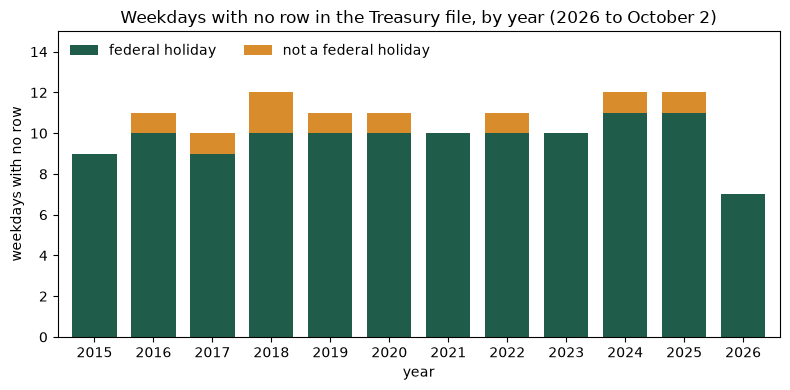

In [18]:
import matplotlib.pyplot as plt

# one row per year: how many missing weekdays were federal holidays, and how many were not
by_year = pd.DataFrame({
    "federal holiday": pd.Series(missing.intersection(federal.index).year).value_counts(),
    "not a federal holiday": pd.Series(not_federal.year).value_counts(),
}).fillna(0).astype(int).sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
by_year.plot.bar(stacked=True, ax=ax, color=["#1f5c4a", "#d98c2b"], width=0.75, rot=0)
ax.set_title("Weekdays with no row in the Treasury file, by year (2026 to October 2)")
ax.set_xlabel("year")
ax.set_ylabel("weekdays with no row")
# headroom above the bars for the legend
ax.set_ylim(0, 15)
ax.legend(frameon=False, ncols=2, loc="upper left")
plt.tight_layout()
plt.show()

* 9 to 11 federal holidays with no row in each full year, and an orange block in most years: the Good Fridays and 2018-12-05. 2026 stops at 2026-10-02, so it is short.
* The counts in the chart are counts of rows the file does not have. The `fillna(0)` here fills a table of **counts** (a year with no orange day has zero of them), not a market series.

## 3.4 FRED's `.` Rows and Treasury's Absent Rows: the Same Days

Treasury's file simply has no row on a day with no curve. FRED's API does it differently: a weekday with no value is a row whose value is `"."`. Day 2 read that `.` as `NaN` and kept it. Today's question: are FRED's `.` days exactly the days the file skips?

Q. Parse the FRED-format sample with `md.parse_fred_observations` and find its `NaN` rows.

In [19]:
import json

sample_body = json.loads(Path("course3_fred_format_dgs10.json").read_text(encoding="utf-8"))
sample = md.parse_fred_observations(sample_body, "DGS10")

sample_nan = sample.index[sample.isna()]
print(f"{len(sample)} rows from {sample.index[0]:%Y-%m-%d} to {sample.index[-1]:%Y-%m-%d}; NaN on {list(sample_nan.strftime('%Y-%m-%d'))}")
print(f"those dates in the file's missing weekdays: {sample_nan.isin(missing).all()}")

43 rows from 2026-08-03 to 2026-09-30; NaN on ['2026-09-07']
those dates in the file's missing weekdays: True


* 43 rows and one `NaN`, on 2026-09-07: Labor Day, the date the file has no row for.

Q. Check the whole span: the sample's numeric dates against the file's rows.

In [20]:
# the file's rows over the sample's span, and the sample's dates that hold a number
file_span = treasury.loc[sample.index[0]:sample.index[-1], "10 Yr"]
sample_numbers = sample.dropna()

print(f"same dates: {list(sample_numbers.index) == list(file_span.index)}")
print(f"largest gap in value: {(sample_numbers - file_span).abs().max():.1e} percent")

same dates: True
largest gap in value: 0.0e+00 percent


* The same 42 dates and the same values: the sample was built from the file, so this is the expected answer. The live cell below asks the same question of FRED's whole `DGS10` history.

*This product uses the FRED&reg; API but is not endorsed or certified by the Federal Reserve Bank of St. Louis.*

Q. Run the key cell.

In [21]:
try:
    fred_key = md.get_secret("FRED_API_KEY", env_file=ENV_FILE)
    print("FRED key: found. It is held in memory and is never printed.")
except RuntimeError as error:
    fred_key = None
    print(f"FRED key: not found. Live cells will be skipped. {error}")

FRED key: not found. Live cells will be skipped. Secret FRED_API_KEY not found. Looked in: the environment variable FRED_API_KEY, Colab's Secrets panel, and the file .env given as env_file.


* The saved notebook was run with no key, so it says `not found`. With your key in place (day 1, section 1.10) it says `found`.

Q. Pull `DGS10` from 2015 with `md.fred_series`. Are its `.` rows the file's missing weekdays, date for date?

In [22]:
# a live cell: it needs your key and the network
if fred_key is None:
    print(NO_KEY_MESSAGE)
else:
    live_dgs10 = md.fred_series("DGS10", fred_key, start="2015-01-01")
    # compare over the span both cover: from the file's first date to whichever source ends first
    live_end = min(live_dgs10.index[-1], treasury.index[-1])
    live_span = live_dgs10.loc[treasury.index[0]:live_end]
    live_dots = live_span.index[live_span.isna()]
    live_expected = missing[missing <= live_end]
    print(f"FRED rows {treasury.index[0]:%Y-%m-%d} to {live_end:%Y-%m-%d}: {len(live_span):,}, of them '.': {len(live_dots)}")
    print(f"weekend rows: {(live_span.index.dayofweek >= 5).sum()}")

    # the checks: the '.' days are the file's missing weekdays, and the numbers equal the file on every date
    assert list(live_dots) == list(live_expected), "FRED's '.' days differ from the file's missing weekdays"
    live_numbers = live_span.dropna()
    assert list(live_numbers.index) == list(treasury.loc[:live_end].index), "FRED's numeric dates differ from the file's rows"
    live_gap = (live_numbers - treasury.loc[:live_end, "10 Yr"]).abs().max()
    assert live_gap <= 1e-9, "FRED and the snapshot disagree"
    print(f"'.' days equal the {len(live_expected)} missing weekdays; values equal on {len(live_numbers):,} dates, largest gap {live_gap:.1e} percent")

Live cell skipped: no FRED key was found. Every other cell runs without one.


* The saved output is the skip message, because the saved run had no key.
* **With your key** you will see the number of FRED rows from 2015-01-02 to the last date both sources have, how many of them are `.`, zero weekend rows, and the check line: FRED's `.` days are exactly the file's missing weekdays up to that date, and every other row holds the file's number. FRED's history starts before 2015, so the cell compares only from the file's first date.
* Two sources, two ways of writing "no curve today", the same days. Read either one, drop the gaps, and you get the same market calendar.

## 3.5 Joining Two Series: `align`

Most desk questions need two series side by side: a yield and a spread, two tenors, a file and a live pull. pandas joins them on the date index. The question is **which dates to keep**:

* **inner**: only the dates every series has.
* **outer**: every date any series has, with `NaN` where a series has no row.

`align` does one of the two, checks each index first, and **never fills** a gap.

Q. Add `align` to `marketdata.py`.

In [23]:
%%writefile -a marketdata.py


def align(series: dict[str, pd.Series], how: str = "inner") -> pd.DataFrame:
    """Put several dated series side by side, one column each, joined on date.

    Units: each column keeps its own units. Convention: how="inner" keeps the dates every series has;
    how="outer" keeps every date any series has and leaves NaN where a series has no row. Nothing is filled.
    Raises ValueError for any other `how`, or for a series whose index is not unique ascending dates.
    """
    # stop on a join the course does not use
    if how not in ("inner", "outer"):
        raise ValueError(f"how must be 'inner' or 'outer', not {how!r}")
    for name, values in series.items():
        _check_index(values.index, name)
    # one column per series, named by its key
    frame = pd.concat(series, axis=1, join=how)
    # an outer join can mix the order of dates, so sort them
    frame = frame.sort_index()
    frame.index.name = "date"
    return frame

Appending to marketdata.py


* `pd.concat` with a dictionary makes one column per series, named by its key, and `join=` picks inner or outer. Anything else stops with a `ValueError` before any work is done.

Q. Reload, then join the file's 10 Yr with the parsed FRED sample, outer, over the sample's span. Look at Labor Day.

In [24]:
importlib.reload(md)

# the parsed sample still holds its NaN row; the file has no row that day
both = md.align({"file": file_span, "fred": sample}, how="outer")
print(f"{len(both)} rows")
both.loc["2026-09-03":"2026-09-09"]

43 rows


,file,fred
date,,
2026-09-03,4.77,4.77
2026-09-04,4.78,4.78
2026-09-07,NaN,NaN
2026-09-08,4.80,4.80
2026-09-09,4.83,4.83


* 43 rows, one more than the market had: the outer join kept 2026-09-07 because the sample has a row there, and put `NaN` in both columns. **An outer join puts `NaN` in the gaps, and it can bring in a date the market never had.**
* That is why the `.` rows are dropped before a join that feeds a number.

Q. Drop the sample's `NaN` row first and join inner.

In [25]:
clean = md.align({"file": file_span, "fred": sample.dropna()})
print(f"{len(clean)} rows, values equal on every row: {(clean['file'] == clean['fred']).all()}")

42 rows, values equal on every row: True


* 42 rows, one per market day, and the two columns agree.

Q. Where an outer join earns its place: a tenor that starts later than the rest. The `4 Mo` column is blank before its first date. Join it with the 10 Yr both ways.

In [26]:
four_month = treasury["4 Mo"].dropna()
inner = md.align({"10 Yr": treasury["10 Yr"], "4 Mo": four_month})
outer = md.align({"10 Yr": treasury["10 Yr"], "4 Mo": four_month}, how="outer")

print(f"4 Mo starts {four_month.index[0]:%Y-%m-%d}")
print(f"inner: {len(inner):,} rows from {inner.index[0]:%Y-%m-%d}")
print(f"outer: {len(outer):,} rows from {outer.index[0]:%Y-%m-%d}, with {outer['4 Mo'].isna().sum():,} NaN in 4 Mo")

4 Mo starts 2022-10-19
inner: 989 rows from 2022-10-19
outer: 2,940 rows from 2015-01-02, with 1,951 NaN in 4 Mo


* Inner keeps the 989 rows from 2022-10-19, when both have a value. Outer keeps all 2,940, and the 1,951 rows before 2022-10-19 are `NaN` in `4 Mo`: honest, because there was no 4-month yield in this file then.
* Choose by the question. A spread between two series needs both on the same day: inner. A table that shows every date of the longer series, gaps visible: outer.

Q. Try a join `align` does not do.

In [27]:
try:
    md.align({"10 Yr": treasury["10 Yr"], "4 Mo": four_month}, how="left")
except ValueError as error:
    print(f"ValueError: {error}")

ValueError: how must be 'inner' or 'outer', not 'left'


* `ValueError: how must be 'inner' or 'outer', not 'left'`. pandas has more kinds of join; this course needs two, and a function that refuses the rest cannot be called with the wrong one by accident.

Q. Write the two `align` tests.

In [28]:
%%writefile -a test_marketdata.py


def test_align_inner_keeps_common_dates():
    dates = pd.to_datetime(["2026-09-03", "2026-09-04", "2026-09-08"])
    ten = pd.Series([5.20, 5.22, 5.25], index=dates)
    spread = pd.Series([98.0, 98.4], index=dates[[0, 2]])
    inner = md.align({"10 Yr": ten, "ig_spread_bp": spread})
    assert list(inner.index) == list(dates[[0, 2]])
    assert list(inner.columns) == ["10 Yr", "ig_spread_bp"]
    # an outer join keeps every date and leaves the gap empty, never filled
    outer = md.align({"10 Yr": ten, "ig_spread_bp": spread}, how="outer")
    assert len(outer) == 3 and math.isnan(outer.loc["2026-09-04", "ig_spread_bp"])


def test_align_rejects_unknown_how():
    ten = pd.Series([5.20], index=pd.to_datetime(["2026-09-03"]))
    with pytest.raises(ValueError):
        md.align({"10 Yr": ten}, how="left")

Appending to test_marketdata.py


* The first builds three dates and a spread with one of them missing: inner keeps two, outer keeps three and leaves the gap `NaN`, never filled. The second checks the refusal.

## 3.6 Forward Fill: for Display Only

`ffill()` (forward fill) replaces each `NaN` with the last value before it. It makes a table look complete, and that is the danger: the filled value looks like data.

Q. Forward fill the file's column of the outer join from section 3.5, and compare the daily changes in bp around Labor Day with and without the fill.

In [29]:
filled = both["file"].ffill()

# daily changes in bp: from each row to the row before it, times 100 because yields are in percent
change_rows = file_span.diff() * 100
change_filled = filled.diff() * 100

table = pd.DataFrame({"10 Yr": file_span, "10 Yr filled": filled,
                      "change bp": change_rows, "change bp filled": change_filled})
table.loc["2026-09-03":"2026-09-09"].round(2)

,10 Yr,10 Yr filled,change bp,change bp filled
date,,,,
2026-09-03,4.77,4.77,-2.0,-2.0
2026-09-04,4.78,4.78,1.0,1.0
2026-09-07,NaN,4.78,NaN,0.0
2026-09-08,4.80,4.80,2.0,2.0
2026-09-09,4.83,4.83,3.0,3.0


* The fill invented a 10 Yr of 4.78 on Labor Day, Friday's value, and with it a **change of 0.00 bp** on a day the market had no curve.
* Tuesday's change is 2.00 bp either way: from Friday on the market rows, from the invented Monday when filled.

Q. Does one invented day matter? Compare the changes over the whole span.

In [30]:
for label, changes in [("market rows", change_rows.dropna()), ("filled", change_filled.dropna())]:
    print(f"{label:12} {len(changes)} changes, {(changes.round(6) == 0).sum()} of them zero, "
          f"mean absolute change {changes.abs().mean():.3f} bp, standard deviation {changes.std():.3f} bp")

market rows  41 changes, 3 of them zero, mean absolute change 3.976 bp, standard deviation 4.909 bp
filled       42 changes, 4 of them zero, mean absolute change 3.881 bp, standard deviation 4.854 bp


* One more change, one more zero (3 on the market rows, 4 filled), a smaller average move (3.976 against 3.881 bp) and a smaller standard deviation (4.909 against 4.854 bp). A full year has 9 to 11 federal holidays with no row alone, and every volatility or z-score built on filled data is computed partly from days that never happened.
* **The rule:** a missing day is never filled for a calculation. Forward fill is allowed for display, on a copy, labelled, and never before a change, a window, or a join that feeds a number.

## 3.7 Stale Values: `stale_runs`

A gap is a day with no value. A **stale** value is the opposite problem: a row that is there, holding yesterday's number, because a feed stopped updating and kept sending the last value it had. It looks like data and changes nothing, so it shows up as a run of zero changes.

`stale_runs` finds every run of the same value on consecutive rows that is at least `min_length` long. It refuses a series with `NaN` in it, because a gap between two equal values would hide or split a run: drop the gaps first.

Q. Add `stale_runs` to `marketdata.py`.

In [31]:
%%writefile -a marketdata.py


def stale_runs(series: pd.Series, min_length: int = 3) -> pd.DataFrame:
    """Runs of the same value repeated on consecutive observations: a sign of a value that stopped updating.

    Units: `value` has the series' units, `length` counts observations. Convention: consecutive means
    consecutive rows, whatever the calendar gap. One row per run of at least `min_length` identical values,
    with columns start, end, length, value.
    Raises ValueError if min_length is below 2, the series has missing values (drop them first), or its index
    is not unique ascending dates.
    """
    _check_index(series.index, "series")
    if min_length < 2:
        raise ValueError(f"min_length must be at least 2, not {min_length}")
    if series.isna().any():
        raise ValueError(f"series has {series.isna().sum()} missing values; drop them first with .dropna()")
    # a new run starts wherever the value differs from the row before
    run_id = (series != series.shift()).cumsum()
    runs = []
    for _, run in series.groupby(run_id):
        # keep runs long enough to report
        if len(run) >= min_length:
            runs.append({"start": run.index[0], "end": run.index[-1], "length": len(run), "value": run.iloc[0]})
    return pd.DataFrame(runs, columns=["start", "end", "length", "value"])

Appending to marketdata.py


* The run counter is one line: `series != series.shift()` is `True` wherever the value differs from the row before, and `cumsum()` adds those up, so every row of a run shares one number. `groupby` on that number visits each run once.

Q. Reload, then look for runs of three or more in each synthetic spread.

In [32]:
importlib.reload(md)

for column in ["ig_spread_bp", "hy_spread_bp"]:
    runs = md.stale_runs(spreads[column], min_length=3)
    print(f"{column}: {len(runs)} runs of 3 or more")
md.stale_runs(spreads["ig_spread_bp"], min_length=3)

ig_spread_bp: 4 runs of 3 or more


hy_spread_bp: 0 runs of 3 or more

,start,end,length,value
0,2015-02-13,2015-02-18,3,84.7
1,2021-12-08,2021-12-10,3,81.3
2,2024-02-14,2024-02-16,3,107.2
3,2025-11-21,2025-11-25,3,92.2


* The investment grade spread has 4 runs of exactly three rows; the high yield spread has none. Both are quoted to one decimal in bp, and an unchanged value for three days happens.

Q. And runs of five or more, and of two or more?

In [33]:
for column in ["ig_spread_bp", "hy_spread_bp"]:
    print(f"{column}: runs of 5 or more {len(md.stale_runs(spreads[column], min_length=5))}, "
          f"runs of 2 or more {len(md.stale_runs(spreads[column], min_length=2))}")

ig_spread_bp: runs of 5 or more 0, runs of 2 or more 107


hy_spread_bp: runs of 5 or more 0, runs of 2 or more 29


* No run of five or more in either series. Runs of two are common: 107 in the investment grade spread, 29 in the high yield spread.
* The length you flag is a choice. Too short and every quiet day is a suspect; too long and a stale week slips through. Five or more is this course's level for "look at this".

Q. Real published data repeats too. Look for runs of three or more in the Treasury file's 2 Yr.

In [34]:
two_year_runs = md.stale_runs(treasury["2 Yr"].dropna(), min_length=3)
print(f"2 Yr: {len(two_year_runs)} runs of 3 or more, the longest {two_year_runs['length'].max()} rows")
two_year_runs[two_year_runs["length"] == two_year_runs["length"].max()]

2 Yr: 84 runs of 3 or more, the longest 8 rows


,start,end,length,value
54,2020-12-16,2020-12-28,8,0.13
65,2021-05-10,2021-05-19,8,0.16


* 84 runs in the 2 Yr, the longest 8 rows (from 2020-12-16 to 2020-12-28 and from 2021-05-10 to 2021-05-19). A yield published to two decimals can sit still for days.
* So a run is **a reason to look, not a verdict**. `stale_runs` tells you where; another source, or the person who sends the file, tells you whether.

Q. Write the last of today's tests, then run them all.

In [35]:
%%writefile -a test_marketdata.py


def test_stale_runs_finds_a_run():
    dates = pd.bdate_range("2026-09-01", periods=7)
    values = pd.Series([98.1, 98.4, 98.4, 98.4, 98.4, 98.2, 98.2], index=dates)
    runs = md.stale_runs(values, min_length=3)
    # one run of four, from the second row to the fifth; the pair at the end is too short
    assert len(runs) == 1
    assert runs.loc[0, "start"] == dates[1] and runs.loc[0, "end"] == dates[4]
    assert runs.loc[0, "length"] == 4 and runs.loc[0, "value"] == 98.4

Appending to test_marketdata.py


In [36]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_marketdata.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

.............                                                            [100%]
13 passed in 1.04s



* `13 passed`: day 2's 9 and today's four.

## Excel Side by Side

Excel has date functions built for working days, and they take a holiday list. Every line below was tested in Excel 16.0 build 20430, 2026-10-04, on a sheet holding the Treasury file's dates in column A (rows 2 to 2941), its 10 Yr in B, the synthetic `ig_spread_bp` in C, and the 7 missing weekdays of 2026 in H2:H8.

| Job | Python | Excel (tested) | Excel returns |
| --- | --- | --- | --- |
| Day of the week | `date.dayofweek + 1` (Monday 1) | `=WEEKDAY(DATE(2026,9,4),2)` | 5 (Friday); Monday 2026-09-07 gives 1, Sunday 7 |
| The same, no second argument | | `=WEEKDAY(DATE(2026,9,6))` | 1: Sunday counts as 1 |
| Weekdays with no row in the file | `len(md.missing_weekdays(...))` | `=NETWORKDAYS(A2,A2941)-COUNT(A2:A2941)` | 126 (3,066 weekdays less 2,940 dates) |
| Weekdays in 2026 to October 2 | `len(pd.bdate_range(...))` | `=NETWORKDAYS(DATE(2026,1,1),DATE(2026,10,2))` | 197 |
| Market days in 2026 | `len(treasury.loc["2026"])` | `=NETWORKDAYS(DATE(2026,1,1),DATE(2026,10,2),H2:H8)` | 190 |
| The next working day after Friday 2026-09-04 | the next row of the index | `=WORKDAY(DATE(2026,9,4),1)` | 2026-09-07 (Labor Day) |
| The same, with the holiday list | | `=WORKDAY(DATE(2026,9,4),1,H2:H8)` | 2026-09-08 |
| The 10 Yr on a day with no row | `treasury.loc["2026-09-07"]` raises `KeyError` | `=XLOOKUP(DATE(2026,9,7),A2:A2941,B2:B2941)` | `#N/A` |
| The 10 Yr the next day | `treasury.loc["2026-09-08", "10 Yr"]` | `=XLOOKUP(DATE(2026,9,8),A2:A2941,B2:B2941)` | 4.8 |
| A run of three equal values | `md.stale_runs(..., min_length=3)` | `=AND(C4=C3,C3=C2)` in D4, filled down to D2941, then `=COUNTIF(D4:D2941,TRUE)` | 4 |

**`WEEKDAY`.** With the second argument 2, Monday is 1 and Friday 5, the same order as pandas' `dayofweek` plus one, so `WEEKDAY(A2,2)>5` marks a weekend. Leave the argument out and Sunday becomes 1: a classic slip when a sheet and a script are compared.

**`NETWORKDAYS` and `WORKDAY` know two things: weekends, and the list you give them.** With no list, `WORKDAY` steps from Friday 2026-09-04 to Monday 2026-09-07, Labor Day. Given the file's own missing weekdays as the list, it steps to Tuesday, and `NETWORKDAYS` over 2026 returns 190, exactly the file's rows. The holiday list is Excel's version of today's rule: the calendar comes from the data. Build the list from the data (as `md.missing_weekdays` does), not from a printed holiday calendar.

**Missing weekdays in one cell.** `NETWORKDAYS` from the first date to the last counts every weekday; `COUNT` counts the dates the sheet has. The difference, 126, is the number of weekdays with no row.

**`XLOOKUP` on a date with no row** returns `#N/A`, as `.loc` raises a `KeyError`. Both refuse to make up a value. Day 4 shows the as-of lookup that takes the last value before a date, on purpose.

**A stale flag.** `=AND(C4=C3,C3=C2)` is `TRUE` on the third row of any run of three equal values. Filled down the spread column and counted, it finds 4, and the four `TRUE` rows are the `end` dates `stale_runs` reports.

Q. Do Python and Excel agree?

In [37]:
# the counts Excel returned in the test, beside the same counts from Python
excel = {"missing weekdays": 126, "market days in 2026": 190,
          "market days in September 2026": 21, "runs of three in ig_spread_bp": 4}
python = {"missing weekdays": len(missing), "market days in 2026": len(treasury.loc["2026"]),
           "market days in September 2026": len(treasury.loc["2026-09"]),
           "runs of three in ig_spread_bp": len(md.stale_runs(spreads["ig_spread_bp"], min_length=3))}
for name in excel:
    print(f"{name}: Excel {excel[name]}, Python {python[name]}, equal {excel[name] == python[name]}")

missing weekdays: Excel 126, Python 126, equal True
market days in 2026: Excel 190, Python 190, equal True
market days in September 2026: Excel 21, Python 21, equal True
runs of three in ig_spread_bp: Excel 4, Python 4, equal True


* Four counts, four matches.

## Save the Day with Git

Today's Git step fixes a commit message. A message is how you, and anyone after you, find a change in the history, so a wrong one is worth fixing, **before anything is built on that commit**. `git commit --amend` replaces the last commit with a new one.

Q. Start a repository in the work folder.

In [38]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1


Q. Is Git working in the work folder, and only there?

In [39]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course3_03_aqi9om27 and nowhere else


Q. Commit the module and the tests, with a message that has a slip in it.

In [40]:
# choose the two files, commit, then list the history one line per commit
!git -C "{work}" add marketdata.py test_marketdata.py
!git -C "{work}" commit -q -m "Add missing_weekdays, align, and stale_run"
!git -C "{work}" log --oneline

ca92158 Add missing_weekdays, align, and stale_run


* The message says `stale_run`, and the function is `stale_runs`. It also leaves out the tests. The commit is a minute old, it is the last one, and nothing is built on it yet: the moment to amend.

Q. Replace the message with `--amend -m`.

In [41]:
# --amend replaces the last commit; -m gives the new message; the files stay as they were
!git -C "{work}" commit --amend -q -m "Add missing_weekdays, align, and stale_runs, with four tests"
!git -C "{work}" log --oneline
!git -C "{work}" show --stat --format=%s HEAD

9a975d0 Add missing_weekdays, align, and stale_runs, with four tests


Add missing_weekdays, align, and stale_runs, with four tests

 marketdata.py      | 215 +++++++++++++++++++++++++++++++++++++++++++++++++++++
 test_marketdata.py | 180 ++++++++++++++++++++++++++++++++++++++++++++
 2 files changed, 395 insertions(+)


* Still one commit, with the right message and the same two files. Its short hash has changed: an amended commit is a new commit, and the old one drops out of the history.
* That is why the rule is **amend only what nobody else has**. Course 9 adds remote repositories; once a commit has been pushed, fix it with a new commit instead.

## Bring It Home

Add today's three functions and four tests to your own `my_bondmath` folder. Open a PowerShell terminal in VS Code, with the course's `.venv` active.

**Step 1.** Go to your folder and open the two files.

```powershell
Set-Location "$HOME\projects\my_bondmath"
code marketdata.py
code test_marketdata.py
```

**Step 2.** At the end of `marketdata.py`, paste the code of today's three `%%writefile -a marketdata.py` cells (sections 3.2, 3.5, and 3.7), without their first lines, in that order. At the end of `test_marketdata.py`, paste today's three `%%writefile -a test_marketdata.py` cells the same way. Save both. `marketdata.py` already imports pandas (day 2), and the tests already import `math` and `pytest`.

**Step 3.** Run the tests.

```powershell
python -m pytest -q test_marketdata.py
```

```
.............                                                            [100%]
13 passed in 0.20s
```

**Step 4.** Read what changed, then commit.

```powershell
git diff --stat
git add marketdata.py test_marketdata.py
git commit -m "Add missing_weekdays, align, and stale_runs, with four tests"
git log --oneline -3
```

If the message comes out wrong, and that commit is the last one and has not left your machine, `git commit --amend -m "..."` replaces it.

**If a test fails**, compare your files with the cells, and check the three new functions are below day 2's code, not inside it.

## You Can Now

* Tell calendar days, weekdays, and market days apart, and count each.
* Find the weekdays a series has no row for with `missing_weekdays`, and say why a holiday calendar is not the market calendar.
* Show that FRED's `.` rows and Treasury's absent rows are the same days.
* Join series with `align`, inner or outer, and say what an outer join puts in the gaps.
* Explain why forward fill is for display only, with the zero change it invents.
* Find runs of repeated values with `stale_runs`, and treat a run as a reason to look.
* Count market days in Excel with `NETWORKDAYS` and a holiday list built from the data, and fix a commit message with `git commit --amend`.

Tomorrow, day 4: which observation stands for a week or a month, the date it is labelled with, and the as-of value on a day with no row.

## Exercises

Replace each `...` with your own code, then run the check cell. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It loads the Treasury file and the synthetic spreads, finds the missing weekdays, and defines `check`, a small function that marks your answers.

In [42]:
from pandas.tseries.holiday import USFederalHolidayCalendar

treasury = pd.read_csv("treasury_par_yields.csv", parse_dates=["date"], index_col="date", float_precision="round_trip")
spreads = pd.read_csv("course3_synthetic_spreads.csv", parse_dates=["date"], index_col="date", float_precision="round_trip")
missing = md.missing_weekdays(treasury.index)


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")

### Exercise 1

Q. How many weekdays have no row in 2020, and in 2025? Store the two counts as a tuple in **ex1_counts**, 2020 first. Then find the 2025 missing weekdays that are not in pandas' `USFederalHolidayCalendar`, and store them as a list of `"YYYY-MM-DD"` text in **ex1_not_federal**.

In [43]:
ex1_counts = ...
ex1_not_federal = ...

In [44]:
check("Exercise 1 the counts", ex1_counts, (11, 12))
check("Exercise 1 not a federal holiday", ex1_not_federal, ['2025-04-18'])

Exercise 1 the counts: not attempted yet
Exercise 1 not a federal holiday: not attempted yet


### Exercise 2

Q. Join the 2026 rows of the 5 Yr, `treasury.loc["2026", "5 Yr"]`, with the whole high yield spread, `spreads["hy_spread_bp"]`, using `md.align`. Store the number of rows of the inner join in **ex2_inner_rows**, and the number of `NaN` in the `5 Yr` column of the outer join in **ex2_outer_missing**. Name the columns `5 Yr` and `hy_spread_bp`.

In [45]:
ex2_inner_rows = ...
ex2_outer_missing = ...

In [46]:
check("Exercise 2 inner rows", ex2_inner_rows, 190)
check("Exercise 2 outer NaN", ex2_outer_missing, 2750)

Exercise 2 inner rows: not attempted yet
Exercise 2 outer NaN: not attempted yet


### Exercise 3

Q. Add a function to your module. `market_days_between(index, start, end)` returns the number of market days from `start` to `end`, both included, where the market days are the dates of `index`. Write the docstring first. Use `_check_index` on the index, and raise `ValueError` if `start` is after `end`. Then add a test, `test_market_days_between_counts_rows`, on a small hand-made index around Labor Day 2026, with a `pytest.raises` check. Run pytest, reload the module, and store `md.market_days_between(treasury.index, "2026-09-01", "2026-09-30")` in **ex3_september**.

Write the function in the cell that starts with `%%writefile -a marketdata.py` and the test in the one that starts with `%%writefile -a test_marketdata.py`, and run each of those cells once.

In [47]:
%%writefile -a marketdata.py


# Exercise 3: write market_days_between(index, start, end) below this line

Appending to marketdata.py


In [48]:
%%writefile -a test_marketdata.py


# Exercise 3: write test_market_days_between_counts_rows() below this line

Appending to test_marketdata.py


In [49]:
# run pytest, reload the module, then call your function
ex3_september = ...

In [50]:
check("Exercise 3 market days in September 2026", ex3_september, 21)

Exercise 3 market days in September 2026: not attempted yet


### Exercise 4: AI check

You ask an AI assistant for a function that lists the days the market was closed, and you give it the docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
The weekdays from the first date to the last on which the market had no row.

    Units: dates. Convention: the data's own dates are the market calendar. A weekday with a row was
    open; a weekday without one was closed, whatever the reason. No holiday calendar decides it.
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, and it contains one bug.

In [51]:
# written for this course in the style of an AI assistant's answer. It runs, and it contains one bug.
from pandas.tseries.holiday import USFederalHolidayCalendar
from pandas.tseries.offsets import CustomBusinessDay


def closed_days(index):
    """The weekdays from the first date to the last on which the market had no row.

    Units: dates. Convention: the data's own dates are the market calendar. A weekday with a row was
    open; a weekday without one was closed, whatever the reason. No holiday calendar decides it.
    """
    # the US market's business days: Monday to Friday, less the federal holidays
    business_days = CustomBusinessDay(calendar=USFederalHolidayCalendar())
    open_days = pd.date_range(index[0], index[-1], freq=business_days)
    # every weekday that is not a business day was a closed day
    return pd.bdate_range(index[0], index[-1]).difference(open_days)

Q. Before you run the next cell: the file has 126 weekdays with no row. How many dates will `closed_days` return, and will Good Friday 2025 be among them? Read the function's first two lines of code.

In [52]:
print(f"{len(closed_days(treasury.index))} dates; Good Friday 2025 among them: {pd.Timestamp('2025-04-18') in closed_days(treasury.index)}")

121 dates; Good Friday 2025 among them: False


Q. Test the function against its docstring before you trust it.

In [53]:
# the test, written from the docstring before the code is trusted
closed = closed_days(treasury.index)
print(f"closed_days returns {len(closed)} dates")
# Good Friday 2025 has no row in the file, so it was a closed day
assert pd.Timestamp("2025-04-18") in closed, "a weekday with no row is missing from the result"
# no date in the answer may have a row in the file
assert not closed.isin(treasury.index).any(), "a day with a row is reported as closed"
assert list(closed) == list(md.missing_weekdays(treasury.index)), "the result is not the file's own calendar"
print("closed_days matches the file's own calendar")

closed_days returns 121 dates


AssertionError: a weekday with no row is missing from the result

Q. Read the test's message, fix the function in the cell that defines it, and run that cell and the test again until the test passes. Then store the number of dates the fixed function returns for `treasury.index` in **ex4_count**, and the number of those dates that have a row in the file, `closed_days(treasury.index).isin(treasury.index).sum()`, in **ex4_with_rows**.

In [54]:
# fix the function above and run the test again, then store the two answers
ex4_count = ...
ex4_with_rows = ...

In [55]:
check("Exercise 4 closed days", ex4_count, 126)
check("Exercise 4 closed days with a row", ex4_with_rows, 0)

Exercise 4 closed days: not attempted yet
Exercise 4 closed days with a row: not attempted yet


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```